# GLM analysis on the main task data [sim01]
It uses nilearn and performs the following steps:
1. Load the data from fmriPrep in BIDS format
2. Iterate on the subjects to:
   1. Select the predictors and confounds for the design matrix
   2. Generate 1st level model
   3. Estimate contrast maps
3. Generate group level maps
4. Extract values for the group ROI from the localizer

In [114]:
# Imports
import os
import glob
from nilearn.glm.first_level import first_level_from_bids
#from nilearn.interfaces.bids import save_glm_to_bids
from nilearn.glm import threshold_stats_img
from nilearn import plotting
from nilearn.plotting.cm import _cmap_d as nilearn_cmaps
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from nilearn.glm.second_level import SecondLevelModel
from nilearn.reporting import get_clusters_table
from nilearn.image import math_img, load_img, threshold_img
from nilearn.masking import apply_mask

In [115]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
space_label = "MNI152NLin2009cAsym"
derivatives_folder = "derivatives/fmriprep23/fmriprep"
nilearn_folder = os.path.join(data_dir, "derivatives", "nilearn_glm")
task_label = "UA" # "AA_acq-0500", "AA_acq-0750", "AA_acq-1000", "AA_acq-2500", "UA_acq-0500", "UA_acq-0750", "UA_acq-1000", "UA_acq-2500"
acq_label = '2500'
smoothing_fwhm = 6.0
high_pass_hz = 0.003

In [116]:
# contrast naming
# if task_label == "AA":
#     contrast_name = "Ambiguous - Static"
#     contrast_name_valid = "AmbiguousMinusStatic"
# elif task_label == "UA":
#     contrast_name = "Unambiguous - Static"
#     contrast_name_valid = "UnambiguousMinusStatic"


# this will now change to and we need to split the models into two
contrast_name = "motion - static"
contrast_name_valid = "motionMinusStatic"

In [117]:
# Multiple comparison correction method for single subject level
mcc_method = "fdr"
mcc_param = 0.05
cluster_thres = 50

## 1. Load the data from fmriPrep in BIDS format

In [118]:
# import first level data automatically from fmriPrep derivatives
(
    models,
    models_run_imgs,
    models_events,
    models_confounds,
) = first_level_from_bids(
    data_dir,
    task_label,
    space_label,
    img_filters=[('acq', acq_label)],
    hrf_model="spm",
    noise_model="ar2",
    smoothing_fwhm=smoothing_fwhm,
    high_pass=high_pass_hz,
    slice_time_ref=None,
    n_jobs=15,
    derivatives_folder=derivatives_folder,
)

In [119]:
# Remove all lines of models_events for which trial_type == 'coherent' or 'incoherent'
for i in range(len(models_events)):
    models_events[i][0] = models_events[i][0][models_events[i][0].trial_type != 'coherent']
    models_events[i][0] = models_events[i][0][models_events[i][0].trial_type != 'incoherent']

models_events[0][0]

,onset,duration,trial_type
0,0.0,15.0,discard
1,15.0,30.0,static
3,45.0,120.0,motion
16,165.0,15.0,mae
17,180.0,30.0,static
19,210.0,120.0,motion
33,330.0,15.0,mae
34,345.0,30.0,static
35,375.0,15.0,discard


## 2. Iterate on the subjects in parallel

In [120]:
from joblib import Parallel, delayed

# Define function for first level analysis
def f(idx):

    # fetch model
    model, imgs, events, confounds = (
        models[idx],
        models_run_imgs[idx],
        models_events[idx],
        models_confounds[idx],
    )

    subject = f"sub-{model.subject_label}"

    print(f"Executing for subject {subject}...")

    # trim confounds
    confounds = confounds[0][['csf','csf_derivative1','csf_power2','csf_derivative1_power2',
                                          'trans_x', 'trans_x_derivative1', 'trans_x_power2', 'trans_x_derivative1_power2',
                                          'trans_y', 'trans_y_derivative1', 'trans_y_power2', 'trans_y_derivative1_power2',
                                          'trans_z', 'trans_z_derivative1', 'trans_z_power2', 'trans_z_derivative1_power2',
                                          'rot_x', 'rot_x_derivative1', 'rot_x_power2', 'rot_x_derivative1_power2',
                                          'rot_y', 'rot_y_derivative1', 'rot_y_power2', 'rot_y_derivative1_power2',
                                          'rot_z', 'rot_z_derivative1', 'rot_z_power2', 'rot_z_derivative1_power2',
                                          ]]

    # replace NaNs with 0s in confounds
    confounds = confounds.fillna(0)
    
    # Fit and contrasts
    model.fit(imgs, events, confounds)

    z_map = model.compute_contrast(contrast_name, output_type="z_score")
    t_map = model.compute_contrast(contrast_name, output_type="stat")
    beta_map = model.compute_contrast(contrast_name, output_type="effect_size")

    # save maps to disk
    z_map.to_filename(os.path.join(nilearn_folder,
                                      f"{subject}_task-{task_label}_acq-{acq_label}_stat-z_con-{contrast_name_valid}.nii.gz"))
    t_map.to_filename(os.path.join(nilearn_folder,
                                        f"{subject}_task-{task_label}_acq-{acq_label}_stat-t_con-{contrast_name_valid}.nii.gz"))
    beta_map.to_filename(os.path.join(nilearn_folder,
                                            f"{subject}_task-{task_label}_acq-{acq_label}_stat-beta_con-{contrast_name_valid}.nii.gz")) 
    
    # Threshold z_map and apply mask to t_map and beta_map
    clean_map, threshold = threshold_stats_img(
        z_map, alpha=mcc_param, height_control=mcc_method, cluster_threshold=cluster_thres
    )

    # this might generate errors if the map is empty and hence the mask is empty as well - todo: fix this
    # mask = math_img("img > 0", img=clean_map)
    # t_map_thresholded = threshold_img(t_map, threshold = 0, mask_img = mask)
    # beta_map_thresholded = threshold_img(beta_map, threshold = 0, mask_img = mask)

    # save thresholded maps to disk
    clean_map.to_filename(os.path.join(nilearn_folder,
                                        f"{subject}_task-{task_label}_acq-{acq_label}_stat-z_con-{contrast_name_valid}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.nii.gz"))                                                      
    # t_map_thresholded.to_filename(os.path.join(nilearn_folder,
    #                                   f"{subject}_task-{task_label}_acq-{acq_label}_stat-t_con-{contrast_name_valid}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.nii.gz"))
    # beta_map_thresholded.to_filename(os.path.join(nilearn_folder,
    #                                     f"{subject}_task-{task_label}_acq-{acq_label}_stat-beta_con-{contrast_name_valid}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.nii.gz"))                                           

    # create figure with thresholded map for fun
    plotting.plot_glass_brain(
        clean_map,
        colorbar=True,
        threshold=threshold,
        plot_abs=False,
        display_mode="ortho",
        figure=plt.figure(figsize=(10, 4)),
    )

    plt.savefig(os.path.join(
        nilearn_folder,
        f"{subject}_task-{task_label}_acq-{acq_label}_plot-z_con-{contrast_name_valid}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.png"
        )
    )

    # Export cluster table
    table = get_clusters_table(z_map, threshold, cluster_thres)
    table.to_csv(os.path.join(nilearn_folder,
                              f"{subject}_task-{task_label}_acq-{acq_label}_table-clusters_con-{contrast_name_valid}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.tsv"),sep='\t')
    
    del model, events, confounds, imgs

# Run in parallel
Parallel(n_jobs=15)(delayed(f)(idx) for idx in range(len(models)))


Executing for subject sub-10...
Executing for subject sub-16...
Executing for subject sub-11...
Executing for subject sub-21...
Executing for subject sub-05...
Executing for subject sub-07...
Executing for subject sub-22...
Executing for subject sub-08...
Executing for subject sub-15...
Executing for subject sub-06...
Executing for subject sub-03...
Executing for subject sub-12...
Executing for subject sub-23...
Executing for subject sub-02...
Executing for subject sub-01...


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:321: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:321: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:321: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:321: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/a

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

## 3. Group level analysis

In [121]:
# Multiple comparison correction method for group
mcc_method_g = "fdr"
mcc_param_g = 0.01
cluster_thres_g = 50

In [122]:
# List all zmap nii.gz files
zmap_files = glob.glob(
    os.path.join(nilearn_folder,
        f"sub-*_task-{task_label}_acq-{acq_label}_stat-z_con-{contrast_name_valid}.nii.gz"
    )
)
zmap_files.sort()

subject_list = [os.path.basename(f).split('_')[0] for f in zmap_files]
subject_list

['sub-01',
 'sub-02',
 'sub-03',
 'sub-05',
 'sub-06',
 'sub-07',
 'sub-08',
 'sub-10',
 'sub-11',
 'sub-12',
 'sub-15',
 'sub-16',
 'sub-21',
 'sub-22',
 'sub-23']

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/_utils/param_validation.py:72: UserWarning: The given float value must not exceed 5.049057373242645. But, you have given threshold=inf.
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:438: UserWarning: empty mask
  xmin_, xmax_, ymin_, ymax_, zmin_, zmax_ = get_mask_bounds(


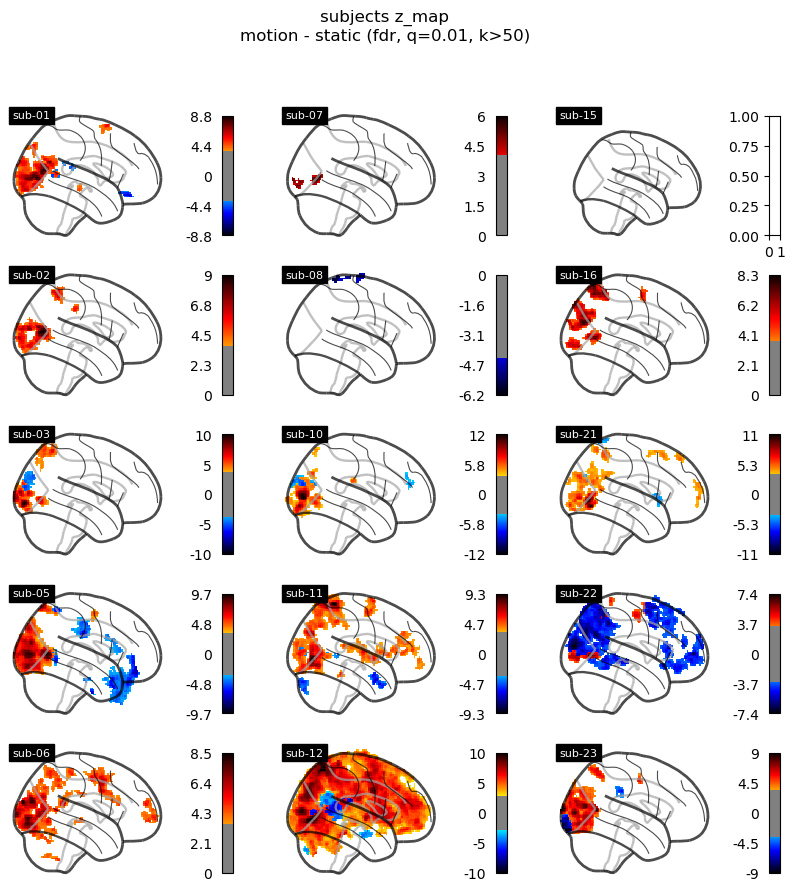

In [123]:
# Plot all subjects
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(10, 10))
for cidx, zmap in enumerate(zmap_files):

    clean_map_g, threshold_g = threshold_stats_img(
        zmap, alpha=mcc_param_g, height_control=mcc_method_g, cluster_threshold=cluster_thres_g
    )

    P = plotting.plot_glass_brain(
        clean_map_g,
        colorbar=True,
        threshold=threshold_g,
        #vmax=25,
        axes=axes[cidx % 5, int(cidx / 5)],
        plot_abs=False,
        display_mode="x",
    )
    P.title(subject_list[cidx], size=8)
    
fig.suptitle(f"subjects z_map\n{contrast_name} ({mcc_method_g}, q={mcc_param_g}, k>{cluster_thres_g})")
plt.show()

In [124]:
# create design matrix for 2nd level
second_level_input = zmap_files
design_matrix_g = pd.DataFrame(
    [1] * len(second_level_input),
    columns=["intercept"],
)

# define 2nd level model
second_level_model = SecondLevelModel(smoothing_fwhm=6.0, n_jobs=20)

second_level_model = second_level_model.fit(
    second_level_input,
    design_matrix=design_matrix_g,
)

# compute contrast (z score map)
z_map_g = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="z_score",
)

# compute contrast (t score map)
t_map_g = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="stat",
)

# compute contrast (beta map)
beta_map_g = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type='effect_size',
)

Threshold: 3.890341849538685


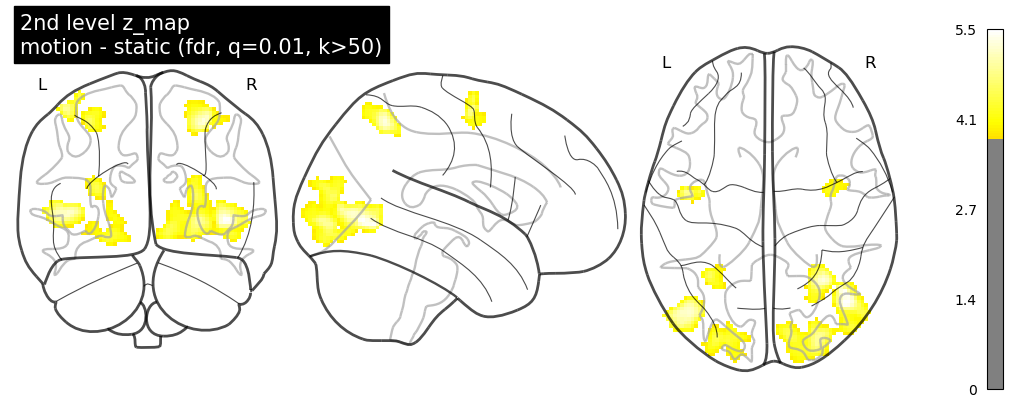

In [125]:
# Threshold zmap and plot it
clean_map_g, threshold_g = threshold_stats_img(
    z_map_g, alpha=mcc_param_g, height_control=mcc_method_g, cluster_threshold=cluster_thres_g
)

print(f"Threshold: {threshold_g}")

plotting.plot_glass_brain(
    clean_map_g,
    colorbar=True,
    threshold=threshold_g,
    plot_abs=False,
    display_mode="ortho",
    #vmin=0,
    #vmax=8,
    figure=plt.figure(figsize=(10, 4)),
    #symmetric_cbar=False,
    cmap=nilearn_cmaps["cold_hot"],
    title=f"2nd level z_map\n{contrast_name} ({mcc_method_g}, q={mcc_param_g}, k>{cluster_thres_g})",
)

plt.savefig(os.path.join(nilearn_folder,"group",
                         f"group_task-{task_label}_acq-{acq_label}_plot-z_con-{contrast_name_valid}_c-{mcc_method_g}_p-{mcc_param_g}_clusterk-{cluster_thres_g}.png"))

t_map_g_thresholded_data_min: 5.362842703699838


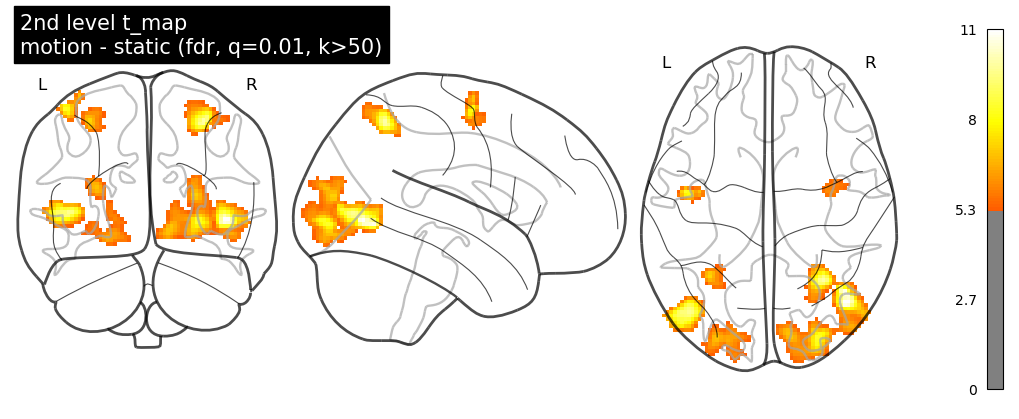

In [126]:
# Apply significance mask from z map threshold to the t map
# This is because applying the threshold_stats_img function to the t map does not work as it should (documentation states the function is only for z maps)

mask = math_img("img > 0", img=clean_map_g)

t_map_g_thresholded = threshold_img(t_map_g, threshold = 0, mask_img = mask)

# find lowest t value in t_map_g_thresholded
t_map_g_thresholded_data = apply_mask(t_map_g_thresholded, mask)
t_map_g_thresholded_data_min = np.min(t_map_g_thresholded_data)

print(f"t_map_g_thresholded_data_min: {t_map_g_thresholded_data_min}")

# plot t_map_g_thresholded
plotting.plot_glass_brain(
    t_map_g_thresholded,
    colorbar=True,
    plot_abs=False,
    display_mode="ortho",
    threshold = t_map_g_thresholded_data_min,
    #vmin=0,
    #vmax=8,
    figure=plt.figure(figsize=(10, 4)),
    #symmetric_cbar=False,
    cmap=nilearn_cmaps["cold_hot"],
    title=f"2nd level t_map\n{contrast_name} ({mcc_method_g}, q={mcc_param_g}, k>{cluster_thres_g})",
)

In [127]:
# Export cluster table
table,cluster_map_g = get_clusters_table(z_map_g, threshold_g, cluster_thres_g,
                                return_label_maps=True)

table.to_csv(os.path.join(nilearn_folder,"group",
                          f"group_task-{task_label}_acq-{acq_label}_table-clusters_con-{contrast_name_valid}_c-{mcc_method_g}_p-{mcc_param_g}_clusterk-{cluster_thres_g}.tsv"),sep='\t')
#print(table)
#print(table.to_latex())
table


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,43.5,-68.5,-0.5,5.482782,10728
1,1a,27.5,-88.5,-2.5,4.924458,
2,1b,27.5,-86.5,13.5,4.596138,
3,1c,13.5,-88.5,-4.5,4.533688,
4,2,31.5,-56.5,55.5,5.280983,2744
5,3,-44.5,-74.5,3.5,5.205847,3272
6,4,-46.5,-6.5,61.5,4.912650,792
7,4a,-38.5,-6.5,67.5,4.515680,
8,5,-32.5,-54.5,55.5,4.605797,920
9,6,-28.5,-88.5,17.5,4.508749,1024


In [128]:
# Save z_map_g, t_map_g, beta_map_g
z_map_g.to_filename(os.path.join(nilearn_folder,"group",
                                 f"group_task-{task_label}_stat-z_con-{contrast_name_valid}.nii.gz"))

t_map_g.to_filename(os.path.join(nilearn_folder,"group",
                                    f"group_task-{task_label}_stat-t_con-{contrast_name_valid}.nii.gz"))

beta_map_g.to_filename(os.path.join(nilearn_folder,"group",
                                    f"group_task-{task_label}_stat-beta_con-{contrast_name_valid}.nii.gz"))

# Save thresholded z_map, t_map and beta map
clean_map_g.to_filename(os.path.join(nilearn_folder,"group",
                                     f"group_task-{task_label}_stat-z_con-{contrast_name_valid}_c-{mcc_method_g}_p-{mcc_param_g}_clusterk-{cluster_thres_g}.nii.gz"))

t_map_g_thresholded.to_filename(os.path.join(nilearn_folder,"group",
                                                f"group_task-{task_label}_stat-t_con-{contrast_name_valid}_c-{mcc_method_g}_p-{mcc_param_g}_clusterk-{cluster_thres_g}.nii.gz"))

beta_map_g_thresholded = threshold_img(beta_map_g, threshold = 0, mask_img = mask)      
 
beta_map_g_thresholded.to_filename(os.path.join(nilearn_folder,"group",
                                                f"group_task-{task_label}_stat-beta_con-{contrast_name_valid}_c-{mcc_method_g}_p-{mcc_param_g}_clusterk-{cluster_thres_g}.nii.gz"))                                         

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



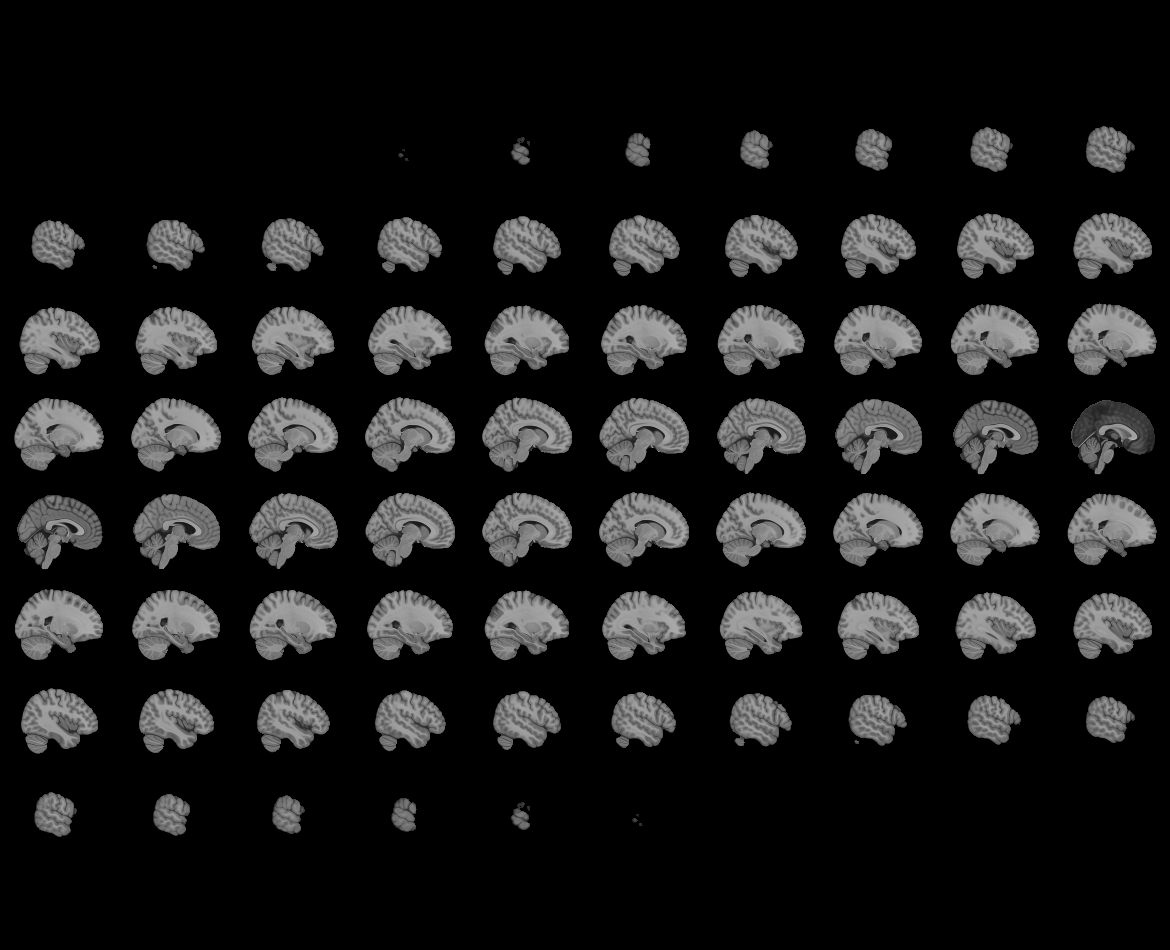
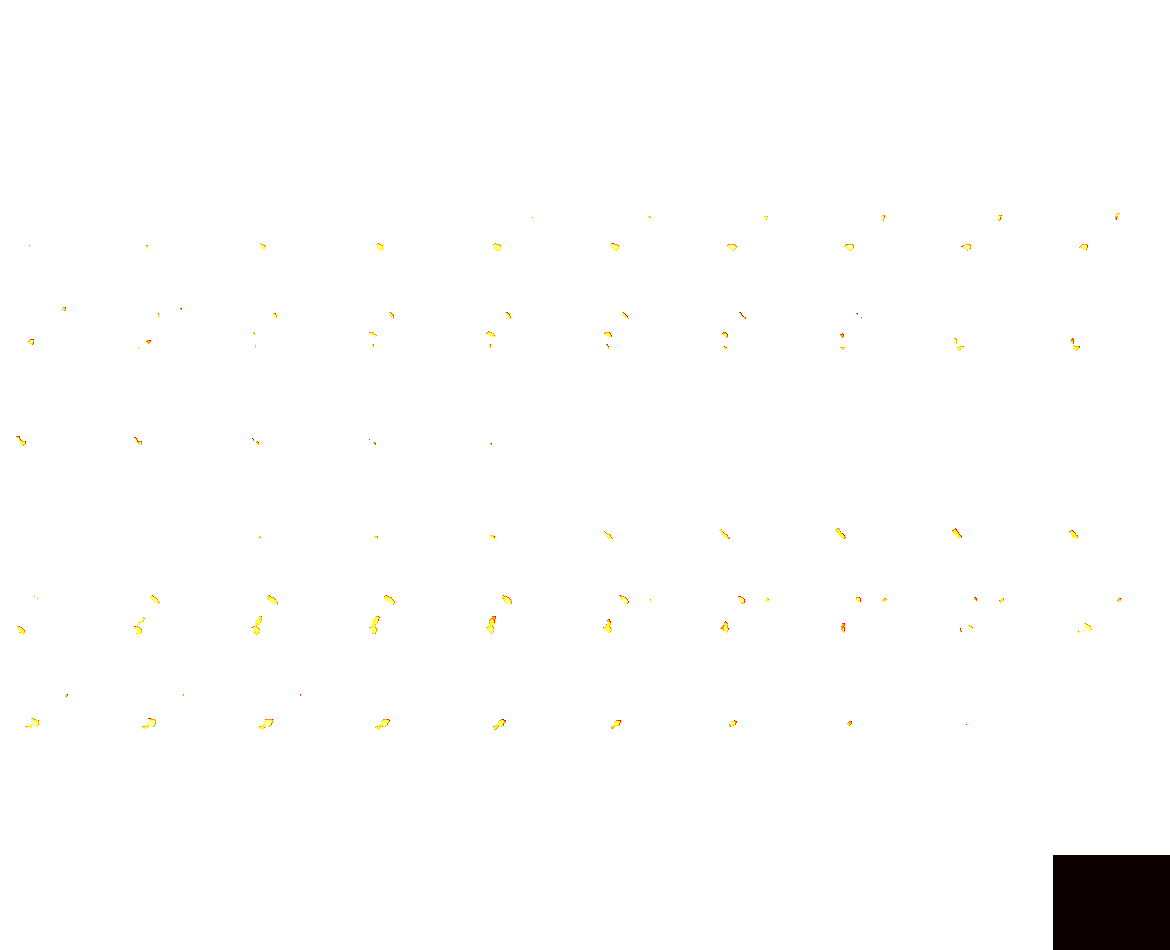

In [129]:
# View map interactively
plotting.view_img(clean_map_g,
         threshold=threshold_g
        )

# ROI analysis

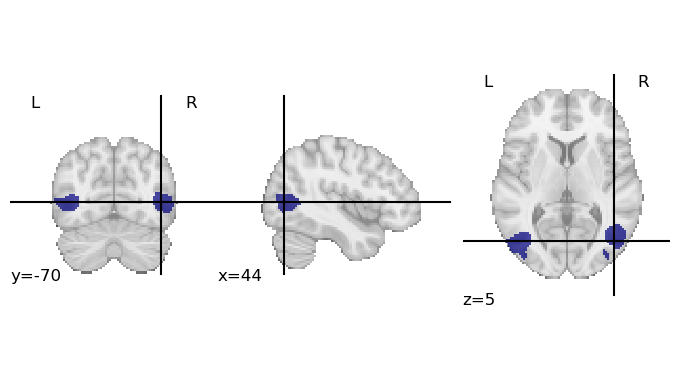

In [130]:
# Load mask from group GLM
mask_hMT = load_img(os.path.join(nilearn_folder,"group",'mask_hMT.nii.gz'))

plotting.plot_roi(mask_hMT)

In [131]:
# mcc_method = "fdr"
# mcc_param = 0.05
# cluster_thres = 50

# List all tmap nii.gz files
tmap_files = glob.glob(
    os.path.join(nilearn_folder,
        f"sub-*_task-{task_label}_acq-{acq_label}_stat-t_con-{contrast_name_valid}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.nii.gz"
    )
)
tmap_files.sort()

# List all zmap nii.gz files f"{subject}_task-{task_label}_acq-{acq_label}_stat-z_con-{contrast_name_valid}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.nii.gz"))
zmap_files = glob.glob(
    os.path.join(nilearn_folder,
        f"sub-*_task-{task_label}_acq-{acq_label}_stat-z_con-{contrast_name_valid}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.nii.gz"
    )
)
zmap_files.sort()

# List all beta nii.gz files
beta_files = glob.glob(
    os.path.join(nilearn_folder,
        f"sub-*_task-{task_label}_acq-{acq_label}_stat-beta_con-{contrast_name_valid}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.nii.gz"
    )
)
beta_files.sort()

In [132]:
# apply mask to all t maps
T = apply_mask(tmap_files, mask_hMT)
# apply mask to all z maps
Z = apply_mask(zmap_files, mask_hMT)
# apply mask to all beta maps
B = apply_mask(beta_files, mask_hMT)

In [133]:
# replace zeros with nan - these zeros correspond to voxels inside the mask but not significant in the map
T[T == 0] = np.nan
Z[Z == 0] = np.nan
B[B == 0] = np.nan

In [134]:
# mean per subject excluding nans
MT = np.nanmean(T,axis=1)
MZ = np.nanmean(Z,axis=1)
MB = np.nanmean(B,axis=1)

# export MT as tsv
np.savetxt(os.path.join(nilearn_folder,"group",
                        f"group_task-{task_label}_acq-{acq_label}_table-meanTvaluePerSub_con-{contrast_name_valid}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.tsv"),
            MT,delimiter='\t',fmt='%.4f')

# export MZ as tsv
np.savetxt(os.path.join(nilearn_folder,"group",
                        f"group_task-{task_label}_acq-{acq_label}_table-meanTvaluePerSub_con-{contrast_name_valid}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.tsv"),
            MZ,delimiter='\t',fmt='%.4f')

# export MB as tsv
np.savetxt(os.path.join(nilearn_folder,"group",
                        f"group_task-{task_label}_acq-{acq_label}_table-meanTvaluePerSub_con-{contrast_name_valid}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.tsv"),
            MB,delimiter='\t',fmt='%.4f')



/tmp/ipykernel_30857/2382182146.py:3: RuntimeWarning: Mean of empty slice
  MZ = np.nanmean(Z,axis=1)


In [135]:
# mean of MT
np.nanmean(MZ)

4.617879920364358